# Setup

In [1]:
import polars as pl 
import matplotlib.pyplot as plt
from collections import Counter
import os 

# Set the font family to Arial
# https://g.co/gemini/share/3898a74b2d77
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial'] # Add Arial to the sans-serif list

plt.rcParams.update({
    'font.size': 20,
})

# Check if the environment variable in .env was actually set in the shell
print(f"PYTHONPATH: {os.environ.get('PYTHONPATH')}")

pl.Config.set_tbl_rows(10) 

PYTHONPATH: /scratch/ucgd/lustre-labs/quinlan/u6018199/tapestry-tools/src/tapestry_tools


polars.config.Config

# Read candidate imprinted loci 

In [2]:
from read_data import read_dataframe_from_bed

def read_imprinted_candidates(bed): 
    df = read_dataframe_from_bed(bed)
    df = df.with_columns(
        pl.col("imprinted_samples").str.split(",")
    )
    return df

DF_IMPRINTED_CANDIDATES = read_imprinted_candidates(
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidates.all-samples.bed'
)
DF_IMPRINTED_CANDIDATES

chrom,start,end,imprinted_samples,num_imprinted_samples,locus
str,i64,i64,list[str],i64,str
"""chr1""",68050000,68051000,"[""NA12877"", ""NA12878"", … ""200106""]",19,"""chr1:68050000-68051000"""
"""chr1""",147078000,147079000,"[""NA12878"", ""NA12887"", … ""200087""]",8,"""chr1:147078000-147079000"""
"""chr1""",205850000,205851000,"[""NA12887"", ""200084"", ""200103""]",3,"""chr1:205850000-205851000"""
"""chr1""",247937000,247938000,"[""NA12885"", ""NA12879"", ""200102""]",3,"""chr1:247937000-247938000"""
"""chr2""",36183000,36184000,"[""200084"", ""200101"", … ""200105""]",4,"""chr2:36183000-36184000"""
…,…,…,…,…,…
"""chrX""",151396000,151397000,"[""200081""]",1,"""chrX:151396000-151397000"""
"""chrX""",151397000,151398000,"[""200081""]",1,"""chrX:151397000-151398000"""
"""chrX""",154341000,154342000,"[""200081""]",1,"""chrX:154341000-154342000"""


# Read Akbari et al 2023 truth set

In [3]:
def read_truth_set_imprinted_loci(): 
    df = (
        pl
        .read_csv(
            'Akbari2023CellGenomics.csv', 
            separator=',',
            comment_prefix=None,
            has_header=True,
            null_values="NA"
        )
        .rename({ 
            'Chromosome': 'chrom',
            'Start': 'start',
            'End': 'end',
            'Methylated allele': 'methylated_allele',
            'Name': 'genes',
            'Study(Reference #)': 'study (reference #)',
            '# of individuals could be examined': 'num_samples_examined',
            '# of individuals with partial methylation': 'num_imprinted_samples',
            '% Individuals with partial methylation': 'percent_imprinted_samples',
            '# of tissues could be examined': 'num_tissues_examined',
            '# of tissues with partial methylation': 'num_imprinted_tissues',
            '% tissues with partial methylation': 'percent_imprinted_tissues'
        })
        .with_columns(
            (pl.col('end') - pl.col('start')).alias('length')
        )
    )
    return df.select(['chrom', 'start', 'end', 'length'] + df.columns[3:-1])

DF_IMPRINTED_TRUTH = read_truth_set_imprinted_loci()
DF_IMPRINTED_TRUTH

chrom,start,end,length,methylated_allele,genes,study (reference #),num_samples_examined,num_imprinted_samples,percent_imprinted_samples,num_tissues_examined,num_imprinted_tissues,percent_imprinted_tissues
str,i64,i64,i64,str,str,str,i64,i64,f64,i64,i64,f64
"""chr1""",11501432,11501606,174,"""Maternal""","""PTCHD2""","""Hernandez(31)""",82,20,24.39,25,7,28.0
"""chr1""",21292978,21293090,112,"""Maternal""","""ECE1;LOC100506801""","""Hernandez(31)""",64,0,0.0,27,6,22.22
"""chr1""",32471178,32471396,218,"""Maternal""","""ZBTB8B""","""Joshi(30)""",81,43,53.09,25,12,48.0
"""chr1""",39515809,39516076,267,"""Maternal""","""BMP8A""","""Akbari(32)""",22,1,4.55,23,6,26.09
"""chr1""",39558940,39560069,1129,"""Maternal""","""PPIEL,PABPC4""","""Akbari(32),Court(29),Hernandez…",86,2,2.33,28,3,10.71
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr9""",95312864,95313633,769,"""Maternal""","""FANCC,FANCC_Int1-DMR""","""Akbari(32),Hernandez(31)""",86,58,67.44,29,17,58.62
"""chr9""",97574899,97575448,549,"""Maternal""","""TMOD1""","""Akbari(32)""",82,29,35.37,27,4,14.81
"""chr9""",113088975,113090248,1273,"""Maternal""","""AL449105.5""","""Hernandez(31)""",84,6,7.14,28,5,17.86


# Compare candidate imprinted loci with Akbari et al 2023 truth set

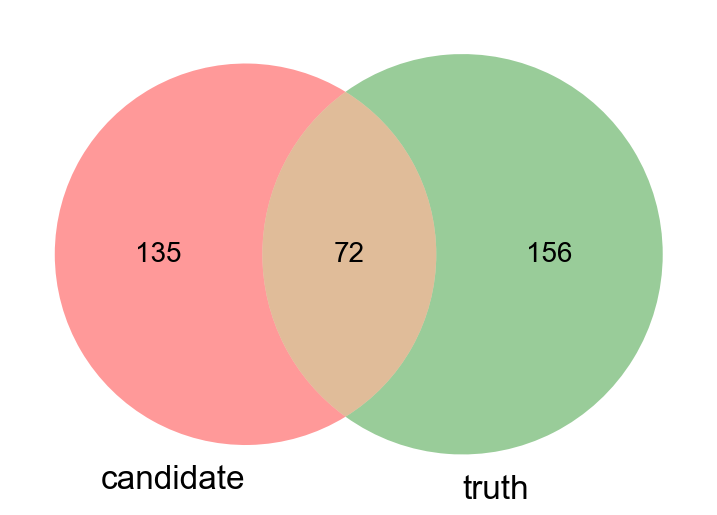

In [4]:
from find_unique_and_common_records import find_unique_and_common_records_with_venn_diagram 

DF_IMPRINTED_CANDIDATES_UNIQUE, DF_IMPRINTED_TRUTH_UNIQUE, DF_IMPRINTED_COMMON = find_unique_and_common_records_with_venn_diagram(
    DF_IMPRINTED_CANDIDATES, 
    DF_IMPRINTED_TRUTH, 
    min_overlap=100, 
    labels=('candidate', 'truth')
)

### Loci common to candidate and truth sets

In [5]:
# Candidate loci recur in intersection of venn diagram because they are small and truth loci are large 
DF_IMPRINTED_COMMON.select([
    'chrom', 'start', 'end', 'num_imprinted_samples',
    'chrom_2', 'start_2', 'end_2', 'length_2',
    'overlap_len'
])

chrom,start,end,num_imprinted_samples,chrom_2,start_2,end_2,length_2,overlap_len
str,i64,i64,i64,str,i64,i64,i64,i64
"""chr1""",68050000,68051000,19,"""chr1""",68046745,68052008,5263,1000
"""chr2""",206250000,206251000,11,"""chr2""",206249709,206274051,24342,1000
"""chr2""",206251000,206252000,6,"""chr2""",206249709,206274051,24342,1000
"""chr2""",206252000,206253000,2,"""chr2""",206249709,206274051,24342,1000
"""chr2""",206256000,206257000,2,"""chr2""",206249709,206274051,24342,1000
…,…,…,…,…,…,…,…,…
"""chr20""",58855000,58856000,14,"""chr20""",58850116,58856591,6475,1000
"""chr20""",58856000,58857000,15,"""chr20""",58850116,58856591,6475,591
"""chr20""",58888000,58889000,17,"""chr20""",58887966,58890443,2477,1000


### Write coordinates of loci in truth-unique set

In [6]:
DF_IMPRINTED_TRUTH_UNIQUE 

chrom,start,end,length,methylated_allele,genes,study (reference #),num_samples_examined,num_imprinted_samples,percent_imprinted_samples,num_tissues_examined,num_imprinted_tissues,percent_imprinted_tissues,locus
str,i64,i64,i64,str,str,str,i64,i64,f64,i64,i64,f64,str
"""chr1""",11501432,11501606,174,"""Maternal""","""PTCHD2""","""Hernandez(31)""",82,20,24.39,25,7,28.0,"""chr1:11501432-11501606"""
"""chr1""",21292978,21293090,112,"""Maternal""","""ECE1;LOC100506801""","""Hernandez(31)""",64,0,0.0,27,6,22.22,"""chr1:21292978-21293090"""
"""chr1""",32471178,32471396,218,"""Maternal""","""ZBTB8B""","""Joshi(30)""",81,43,53.09,25,12,48.0,"""chr1:32471178-32471396"""
"""chr1""",39515809,39516076,267,"""Maternal""","""BMP8A""","""Akbari(32)""",22,1,4.55,23,6,26.09,"""chr1:39515809-39516076"""
"""chr1""",39558940,39560069,1129,"""Maternal""","""PPIEL,PABPC4""","""Akbari(32),Court(29),Hernandez…",86,2,2.33,28,3,10.71,"""chr1:39558940-39560069"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr21""",14063938,14064099,161,"""Maternal""","""LIPI""","""Joshi(30)""",82,8,9.76,25,6,24.0,"""chr21:14063938-14064099"""
"""chr21""",39385480,39386798,1318,"""Maternal""","""WRB""","""Akbari(32),Court(29),Hernandez…",83,34,40.96,28,12,42.86,"""chr21:39385480-39386798"""
"""chr21""",46661115,46661858,743,"""Maternal""","""PRMT2""","""Akbari(32),Zink(6)""",85,24,28.24,29,4,13.79,"""chr21:46661115-46661858"""


In [7]:
from write_data import write_dataframe_to_bed

write_dataframe_to_bed(
    DF_IMPRINTED_TRUTH_UNIQUE, 
    '/scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-truth-unique.all-samples.meth.bed',
    source=globals()["__vsc_ipynb_file__"]
)

In [ ]:
# TODO 
# 2. run compute-methylation-loci to compute methylation at akbari-unique loci
        # Given a set of loci (e.g., imprinted loci), and a set of samples, compute founder-phased methylation averaged over CpGs in each locus: 
        # ```
        # compute-methylation-loci \
        #     --loci-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidates.all-samples.bed \
        #     --sample-meth-beds /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/all-cpgs.all-samples.tsv \
        #     --loci-meth-bed /scratch/ucgd/lustre-labs/quinlan/data-shared/tapestry-tools/CEPH1463.GRCh38.hifi.founder-phased/imprinted-candidates.all-samples.meth.bed
        # ```
# 3. use experiments/b.ipynb to  scatter plot methylation for random subset of akbari-unique loci 
# 4. compute distribution of delta-meth at akbari-unique loci and over all samples 

In [9]:
# TODO
# 1. use gemini to generalize call-imprinted-loci to indicate the methylated allele 
# 2. re-call imprinting candidates
# 3. re-run this notebook, this time comparing candidate and true methylated alleles in DF_IMPRINTED_COMMON